<a href="https://colab.research.google.com/github/zombimann/Mathematical-video-animations-and-visualization/blob/main/Symmetry_of_Powers_and_Roots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Symmetry of Powers and Roots: A Visual Exploration

This project presents a high-fidelity, visually engaging animation created with Python's Matplotlib and NumPy. It illustrates the mathematical beauty and symmetry of inverse functions across the identity line $y=x$.

## Premise
Given Cartesian axes, we visualize the transformation of a variable $x$ by plotting $x^n$ (powers) and $x^{1/n}$ (roots) simultaneously. As $n$ increases from 1 to 15, the animation traces the paths of these functions, demonstrating how they maintain a perfect mirror symmetry relative to the diagonal line $y=x$.

## Technical Implementation
- **Persistence**: Every traced path remains on the canvas, building a complex symmetric web.
- **Telemetry**: Real-time display of $n$ values and coordinate tracking ($x, y_{pow}, y_{root}$).
- **High Performance**: Rendered using `FFMpegWriter` at 30 FPS for smooth transitions.
- **Theming**: A high-contrast 'Dark Mode' aesthetic optimized for digital viewing and social media.

## Author Credits
- **Author**: Mugambi Ndwiga
- **Instagram**: [@craftsandengineering](https://www.instagram.com/craftsandengineering)

---

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

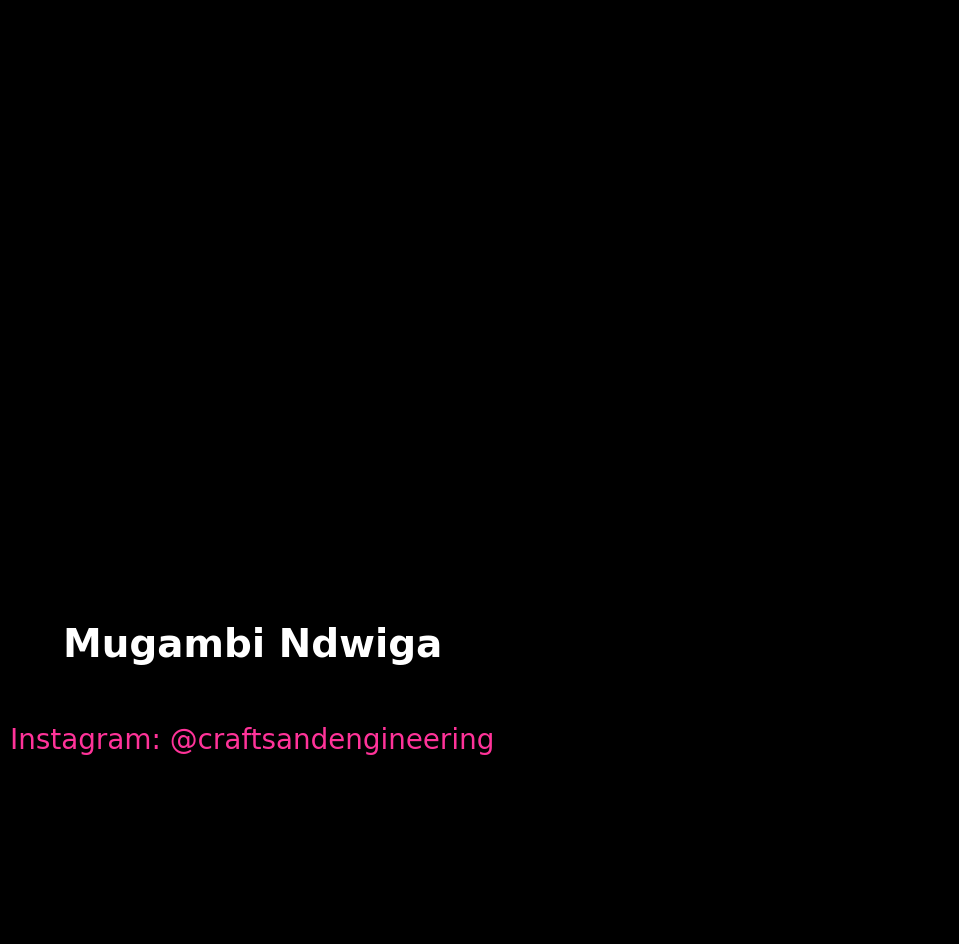

In [4]:
"""
Author: Mugambi Ndwiga
Instagram: @craftsandengineering
Description: High-fidelity persistent animation of power/root symmetry up to n=15.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML
from base64 import b64encode
from google.colab import files

# --- Configuration ---
fig, ax = plt.subplots(figsize=(12, 12), facecolor='black')
ax.set_facecolor('black')
x_full = np.linspace(0.001, 2.0, 200)
n_values = list(range(1, 16))
frames_per_n = 30
total_frames = (len(n_values) * frames_per_n) + 120

# Dynamic elements
curr_line_pow, = ax.plot([], [], lw=2.5, color='#00FFCC')
curr_line_root, = ax.plot([], [], lw=2.5, color='#FF3399')
dot_pow, = ax.plot([], [], 'o', color='white', markersize=6, markeredgecolor='#00FFCC')
dot_root, = ax.plot([], [], 'o', color='white', markersize=6, markeredgecolor='#FF3399')

# Telemetry & Titles
title_text = ax.text(0.5, 1.05, 'The Symmetry of Powers and Roots', transform=ax.transAxes,
                    color='white', ha='center', fontsize=20, fontweight='bold')
telemetry_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, color='#00FFCC', fontsize=12, family='monospace')
watermark = ax.text(0.98, 0.02, 'Author: Mugambi Ndwiga | @craftsandengineering',
                    transform=ax.transAxes, color='white', alpha=0.4, ha='right', fontsize=10)

def init():
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xlabel('X-Axis', color='white', fontsize=12)
    ax.set_ylabel('Y-Axis', color='white', fontsize=12)
    ax.tick_params(colors='white', labelsize=10)
    ax.grid(True, color='white', alpha=0.1, linestyle='--')
    for spine in ax.spines.values():
        spine.set_color('white')
    return curr_line_pow, curr_line_root, dot_pow, dot_root, telemetry_text

def update(frame):
    if frame < len(n_values) * frames_per_n:
        n_idx = frame // frames_per_n
        sub_frame = frame % frames_per_n
        n = n_values[n_idx]

        progress = (sub_frame + 1) / frames_per_n
        idx = int(progress * len(x_full))
        x_seg = x_full[:idx]

        y_pow = x_seg**n
        y_root = x_seg**(1/n)

        curr_line_pow.set_data(x_seg, y_pow)
        curr_line_root.set_data(x_seg, y_root)

        dot_pow.set_data([x_seg[-1]], [y_pow[-1]])
        dot_root.set_data([x_seg[-1]], [y_root[-1]])

        # Update Telemetry
        telemetry = f'n = {n}\nx = {x_seg[-1]:.3f}\ny_pow = {y_pow[-1]:.3f}\ny_root = {y_root[-1]:.3f}'
        telemetry_text.set_text(telemetry)

        # When a segment finishes, make it persistent and add label
        if sub_frame == frames_per_n - 1:
            ax.plot(x_full, x_full**n, lw=1, color='#00FFCC', alpha=0.3)
            ax.plot(x_full, x_full**(1/n), lw=1, color='#FF3399', alpha=0.3)
            if n in [1, 2, 5, 10, 15]:
                ax.text(1.8, 1.8**n, f'$x^{{{n}}}$', color='#00FFCC', fontsize=9)
                ax.text(1.8, 1.8**(1/n), f'$x^{{1/{n}}}$', color='#FF3399', fontsize=9)

    elif frame >= len(n_values) * frames_per_n + 40:
        ax.cla()
        ax.set_facecolor('black')
        ax.axis('off')
        ax.text(0.5, 0.6, 'Mugambi Ndwiga', color='white', ha='center', fontsize=28, fontweight='bold')
        ax.text(0.5, 0.4, 'Instagram: @craftsandengineering', color='#FF3399', ha='center', fontsize=20)

    return curr_line_pow, curr_line_root, dot_pow, dot_root, telemetry_text

ani = FuncAnimation(fig, update, frames=total_frames, init_func=init, blit=False)

# Rendering
writer = FFMpegWriter(fps=30, bitrate=3000)
ani.save('power_root_symmetry.mp4', writer=writer)

# Inline Display
mp4 = open('power_root_symmetry.mp4','rb').read()
data_url = 'data:video/mp4;base64,' + b64encode(mp4).decode()
display(HTML(f'<video width="800" controls autoplay><source src="{data_url}" type="video/mp4"></video>'))
files.download('power_root_symmetry.mp4')